# Core Operations
---

This notebook is a playground for implementing and testing core image operations with Numpy and OpenCV.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from glob import glob
from random import random

import cv2
import matplotlib.pyplot as plt
import numpy as np

In [3]:
file_name = None
# file_name = '../data/misc/4.2.03.tiff'  # Uncomment to use a specific file
if not file_name:
    files = glob('../data/misc/*.tiff')
    file_name = files[int(random() * len(files))]
print(f"Using file: {file_name}")

Using file: ../data/misc/4.1.05.tiff


In [4]:
# Read the image in RGB format (OpenCV uses BGR by default)
image = cv2.imread(file_name, cv2.IMREAD_COLOR_RGB)
# HSV: Hue, Saturation, Value
image_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
# HSL: Hue, Saturation, Lightness
image_hsl = cv2.cvtColor(image, cv2.COLOR_RGB2HLS)

print(f"Image shape: {image.shape}")

Image shape: (256, 256, 3)


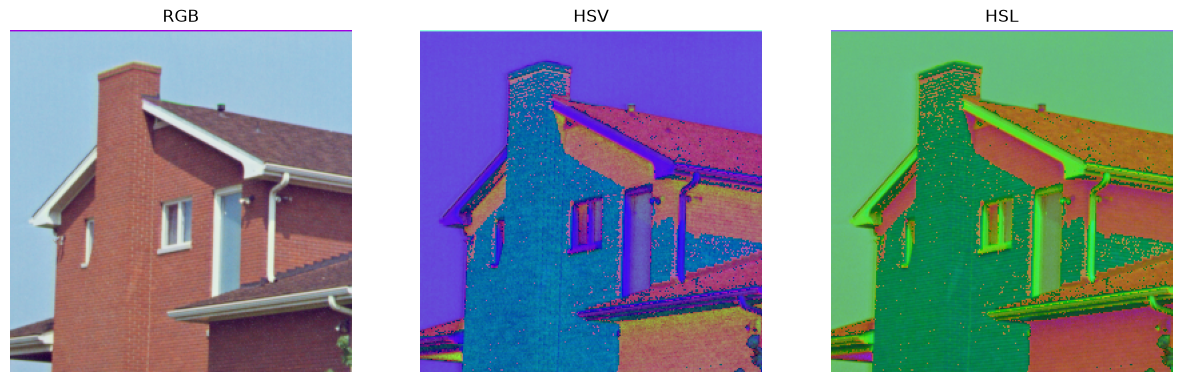

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image)
axes[0].set_title('RGB')
axes[0].axis('off')
axes[1].imshow(image_hsv)
axes[1].set_title('HSV')
axes[1].axis('off')
axes[2].imshow(image_hsl)
axes[2].set_title('HSL')
axes[2].axis('off')
plt.show()

In [6]:
# Under the hood, these are all NumPy arrays
type(image)

numpy.ndarray

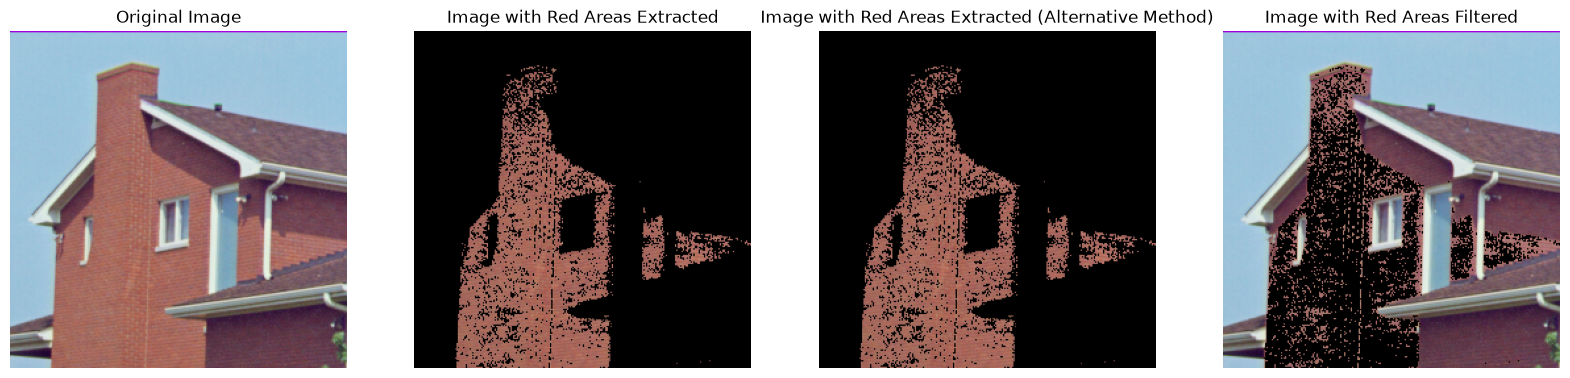

In [23]:
# Apply mask to the image based on the colour (HSV space is often more intuitive for colour-based operations)
lower_red = np.array([0, 100, 100])
upper_red = np.array([10, 255, 255])
mask = cv2.inRange(image_hsv, lower_red, upper_red)
mask2 = mask > 0  # Convert to binary mask (True for red areas, False for non-red areas)
result = cv2.bitwise_and(image, image, mask=mask)  # Note: we use the original RGB image for the bitwise operation to keep the colours
result2 = image * mask2[:, :, np.newaxis]  # Alternative method using broadcasting
result_inv = image * np.logical_not(mask2)[:, :, np.newaxis]  # Inverted mask to get non-red areas
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(image)
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(result)
axes[1].set_title('Image with Red Areas Extracted')
axes[1].axis('off')
axes[2].imshow(result2)
axes[2].set_title('Image with Red Areas Extracted (Alternative Method)')
axes[2].axis('off')
axes[3].imshow(result_inv)
axes[3].set_title('Image with Red Areas Filtered')
axes[3].axis('off')
plt.show()

In [27]:
print(np.size(mask))  # Total number of elements in the mask
print(np.sum(mask > 0))  # Number of pixels that are red (non-zero in the mask)
print(np.sum(mask))  # Total intensity of the red areas (sum of all non-zero values in the mask)

65536
14809
3776295


In [19]:
np.min(result == result2)  # Check if the two methods give the same result (should be True)

np.True_

In [20]:
# Get HSV value for a given colour
red_rgb = np.uint8([[[255, 0, 0]]])  # Red in RGB
red_hsv = cv2.cvtColor(red_rgb, cv2.COLOR_RGB2HSV)
print(f"Red in HSV: {red_hsv[0][0]}")

Red in HSV: [  0 255 255]


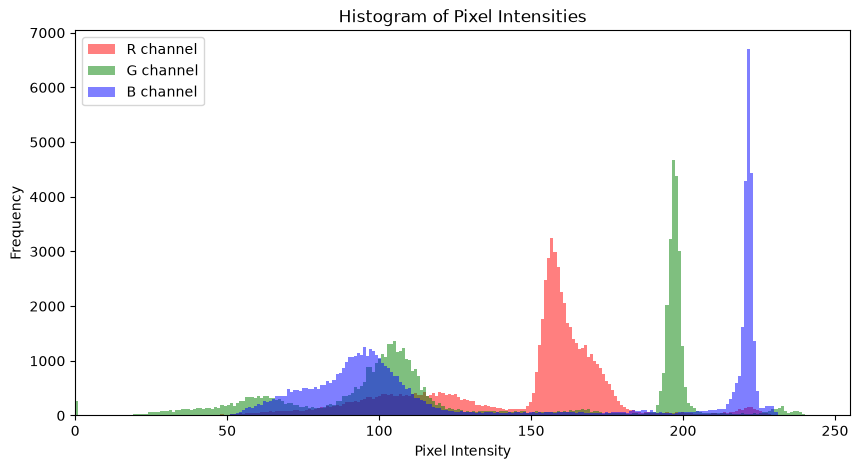

In [21]:
from pyimproc.analysis import histogram_plot
histogram_plot(image)

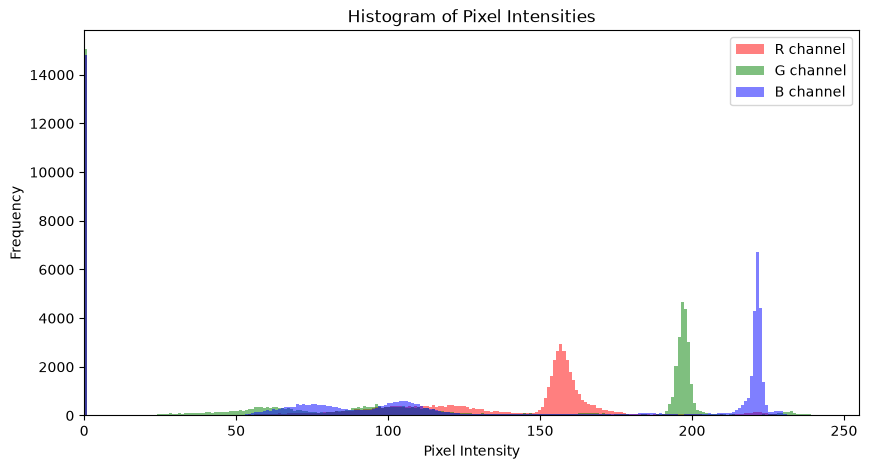

In [26]:
histogram_plot(result_inv)

## Image Arithmetic

In [13]:
file_name2 = "../data/misc/4.1.01.tiff"
image2 = cv2.imread(file_name2, cv2.IMREAD_COLOR_RGB)

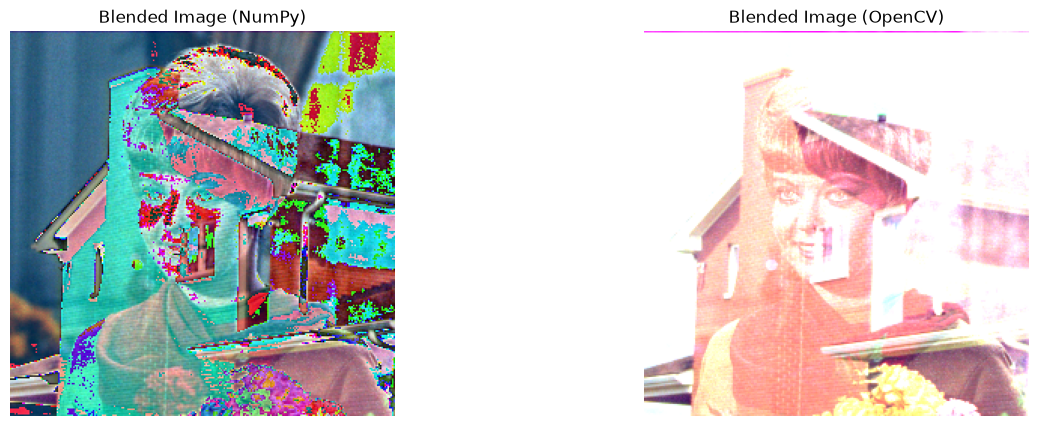

In [14]:
coeffs = [1.5, 1.5]
# coeffs = [0.5, 0.5]  # Uncomment to get identical blending results
image_blend_np = coeffs[0] * image + coeffs[1] * cv2.resize(image2, (image.shape[0], image.shape[1]))
image_blend_cv = cv2.addWeighted(image, coeffs[0], cv2.resize(image2, (image.shape[0], image.shape[1])), coeffs[1], 0)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(image_blend_np.astype(np.uint8))  # Convert to uint8 for proper display
axes[0].set_title('Blended Image (NumPy)')
axes[0].axis('off')
axes[1].imshow(image_blend_cv)
axes[1].set_title('Blended Image (OpenCV)')
axes[1].axis('off')
plt.show()

When adding images Numpy does not normalise the weights, which instead OpenCV does out of the box. 
The two resulting images would be identifical if `coeffs = [0.5, 0.5]`.

---

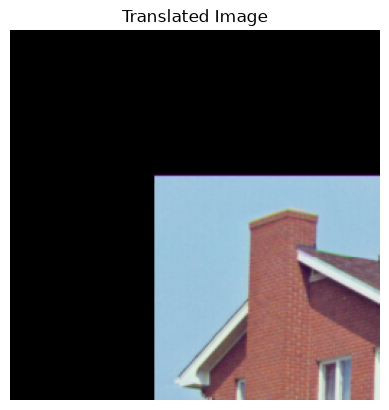

In [15]:
from pyimproc.geometry import translate
translated_image = translate(image, 100, 100)
plt.imshow(translated_image)
plt.title('Translated Image')
plt.axis('off')
plt.show()

Image shape (cropped): (256, 200)


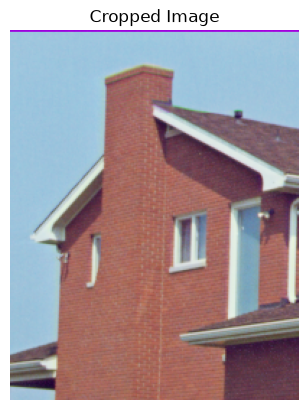

In [36]:
image_cropped = image[:, :200]  # Crop the image to understand rows and columns
rows, cols = image_cropped.shape[:2]
print(f"Image shape (cropped): ({rows}, {cols})")
plt.imshow(image_cropped)
plt.title('Cropped Image')
plt.axis('off')
plt.show()

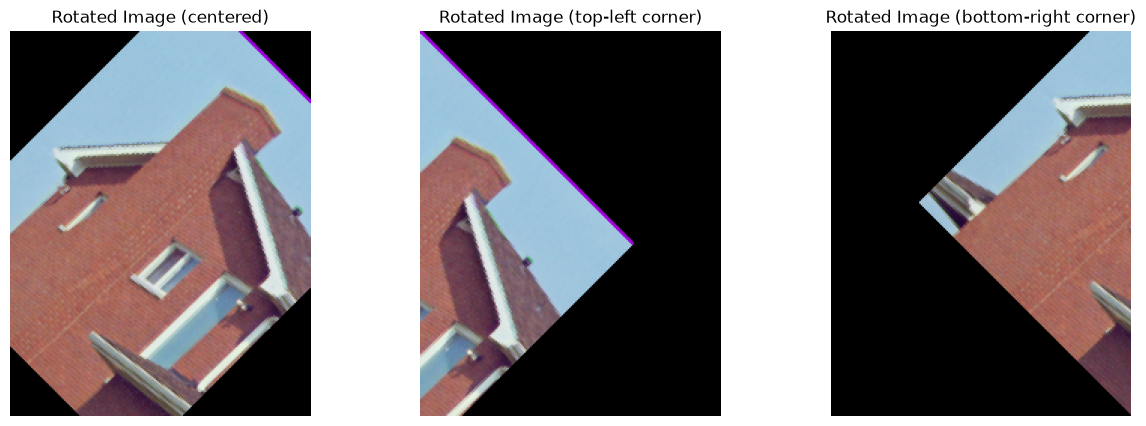

In [39]:
from pyimproc.geometry import rotate
rotated_image = rotate(image_cropped, 45)
rotated_image2 = rotate(image_cropped, 45, center=(0, 0))
rotated_image3 = rotate(
    image_cropped, 45, center=(image_cropped.shape[1], image_cropped.shape[0])
)
# Note: the center is given as (x, y) = (cols, rows) = (width, height)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rotated_image)
axes[0].set_title('Rotated Image (centered)')
axes[0].axis('off')
axes[1].imshow(rotated_image2)
axes[1].set_title('Rotated Image (top-left corner)')
axes[1].axis('off')
axes[2].imshow(rotated_image3)
axes[2].set_title('Rotated Image (bottom-right corner)')
axes[2].axis('off')
plt.show()

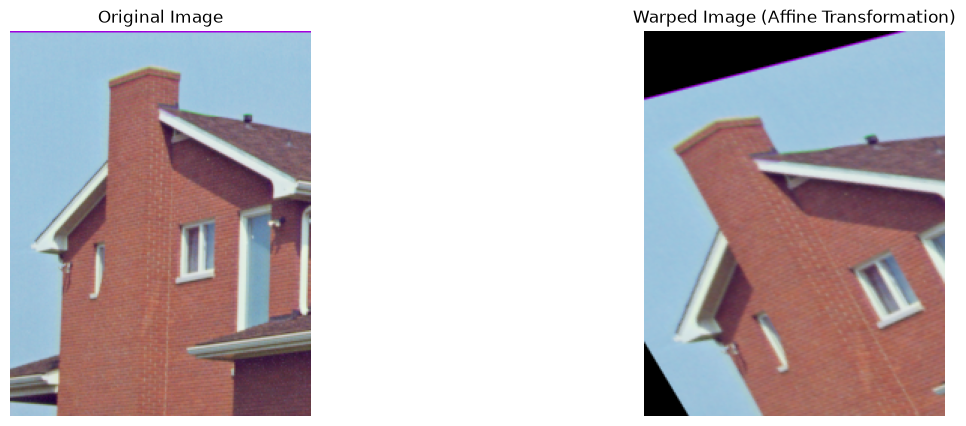

In [40]:
pts1 = np.float32([[50,50],[200,50],[50,200]])
pts2 = np.float32([[10,100],[200,50],[100,250]])

M = cv2.getAffineTransform(pts1,pts2)

image_warped = cv2.warpAffine(image, M, (cols, rows))
# Note: the output size (cols, rows) is given as (width, height) = (x, y)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(image_cropped)
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(image_warped)
axes[1].set_title('Warped Image (Affine Transformation)')
axes[1].axis('off')
plt.show()